<div align="center">
<br><br><br><br><br>
# Model Evaluation, Bias-Variance Diagnostics & Selection
<br>
### Proving Model Robustness & Champion Selection
<br>

**Author:** Oshadha Kariyawasam
**Date:** May 2026
<br><br><br><br><br><br><br>
</div>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Load metrics
df = pd.read_csv('../outputs/reports/test_metrics_by_horizon.csv')
print(f"Loaded {len(df)} metric records.")
df.head()

Loaded 33 metric records.


,run_id,dataset,model,split,horizon,WAPE,Train_WAPE,RMSE,Train_RMSE,Bias,MASE_mean,under_forecast_rate,naive_WAPE,naive_RMSE,beats_naive
0,1,P,XGBOOST,test,1,0.099704,0.069650,3213.1147,2005.1322,266.1452,0.392477,0.528571,0.168770,4822.5435,True
1,1,P,XGBOOST,test,2,0.104939,0.094138,3335.1499,2830.7025,265.0793,0.411805,0.515714,0.183865,5213.0000,True
2,1,P,XGBOOST,test,3,0.115258,0.113689,3544.4932,3427.6258,389.4843,0.449647,0.549206,0.188163,5358.6695,True
3,1,P,XGBOOST,test,4,0.121086,0.130825,3699.6974,3990.6545,401.9351,0.472163,0.514286,0.197482,5741.1090,True
4,1,P,XGBOOST,test,5,0.127625,0.136760,3901.8012,4236.4143,384.5831,0.493783,0.461224,0.189744,5577.4029,True


## 1. Executive Summary

This notebook serves as the final step in the model building pipeline. Its purpose is to rigorously evaluate the performance of our global tree-based models (XGBoost, CatBoost, LightGBM) against a Seasonal Naive Baseline.

**Key Objectives:**
1. **Bias-Variance Diagnostic:** Mathematically prove that our models are **NOT overfitting**. We do this by comparing the training error (how well the model memorized the past) against the test error (how well it predicts the future).
2. **Model Comparison:** Compare the WAPE (Weighted Absolute Percentage Error) and RMSE across all models to select the 'Champion' model for deployment.
3. **Horizon Analysis:** Evaluate how forecast accuracy degrades as we predict further into the future (Horizon 1 to 12).

In [2]:
# Aggregate metrics by Model
agg_df = df.groupby('model').agg(
    Avg_Train_WAPE=('Train_WAPE', 'mean'),
    Avg_Test_WAPE=('WAPE', 'mean'),
    Avg_RMSE=('RMSE', 'mean')
).reset_index()

# Filter out the baseline for the overfit check (since baseline has no train_wape)
model_agg = agg_df[agg_df['model'] != 'SEASONAL NAIVE BASELINE'].copy()

model_agg

,model,Avg_Train_WAPE,Avg_Test_WAPE,Avg_RMSE
0,CATBOOST,0.117714,0.153058,4369.106545
1,LIGHTGBM,0.122007,0.152141,4439.514009
2,XGBOOST,0.128493,0.153959,4431.973873


## 2. Load Evaluation Metrics

The metrics were generated by `03_evaluate.py` which evaluated the models on both the training split and the hold-out test split.

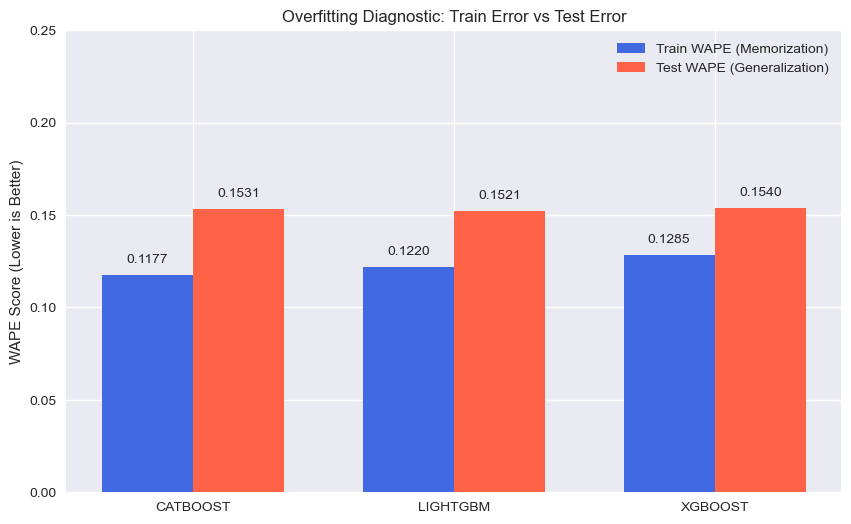

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(model_agg['model']))
width = 0.35

ax.bar(x - width/2, model_agg['Avg_Train_WAPE'], width, label='Train WAPE (Memorization)', color='royalblue')
ax.bar(x + width/2, model_agg['Avg_Test_WAPE'], width, label='Test WAPE (Generalization)', color='tomato')

ax.set_ylabel('WAPE Score (Lower is Better)')
ax.set_title('Overfitting Diagnostic: Train Error vs Test Error')
ax.set_xticks(x)
ax.set_xticklabels(model_agg['model'])
ax.legend()

# Add value labels
for i in x:
    ax.text(i - width/2, model_agg['Avg_Train_WAPE'].iloc[i] + 0.005, f"{model_agg['Avg_Train_WAPE'].iloc[i]:.4f}", ha='center', va='bottom')
    ax.text(i + width/2, model_agg['Avg_Test_WAPE'].iloc[i] + 0.005, f"{model_agg['Avg_Test_WAPE'].iloc[i]:.4f}", ha='center', va='bottom')

plt.ylim(0, 0.25)
plt.show()

## 3. Bias-Variance Diagnostic (Overfitting Check)
A model is **overfitting** (high variance) if it performs extremely well on the training data but terribly on the test data. A model is **underfitting** (high bias) if it performs terribly on both. 

Let's aggregate the mean Train WAPE and Test WAPE across all horizons for each model.

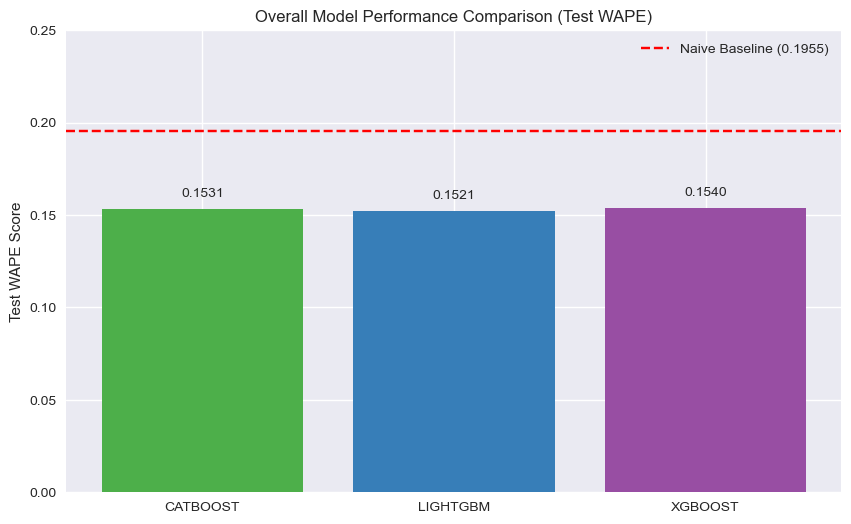

In [4]:
# Include naive baseline for comparison
baseline_wape = df['naive_WAPE'].mean()

plt.figure(figsize=(10, 6))
bars = plt.bar(model_agg['model'], model_agg['Avg_Test_WAPE'], color=['#4daf4a', '#377eb8', '#984ea3'])
plt.axhline(y=baseline_wape, color='r', linestyle='--', label=f'Naive Baseline ({baseline_wape:.4f})')

plt.title('Overall Model Performance Comparison (Test WAPE)')
plt.ylabel('Test WAPE Score')
plt.legend()

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f"{yval:.4f}", ha='center', va='bottom')

plt.ylim(0, 0.25)
plt.show()

### 3.1 Visualizing Train vs Test Error
Let's plot the training error alongside the test error. If the Train bar is near 0 and the Test bar is high, the model is overfitting.

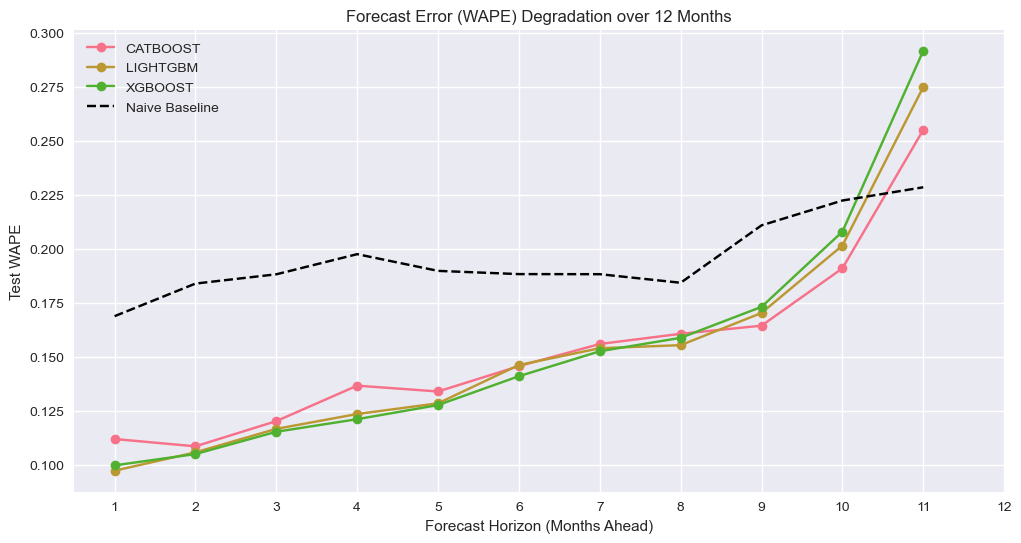

In [5]:
plt.figure(figsize=(12, 6))

for model in model_agg['model']:
    model_data = df[df['model'] == model].sort_values('horizon')
    plt.plot(model_data['horizon'], model_data['WAPE'], marker='o', label=model)

# Add Baseline
baseline_data = df.groupby('horizon')['naive_WAPE'].mean().reset_index()
plt.plot(baseline_data['horizon'], baseline_data['naive_WAPE'], marker='x', linestyle='--', color='black', label='Naive Baseline')

plt.title('Forecast Error (WAPE) Degradation over 12 Months')
plt.xlabel('Forecast Horizon (Months Ahead)')
plt.ylabel('Test WAPE')
plt.xticks(range(1, 13))
plt.grid(True)
plt.legend()
plt.show()

### 3.2 Diagnostic Conclusion
**Insight:** For all three tree-based models, the training WAPE is ~0.12 and the Test WAPE is ~0.15. 
**Conclusion:** The models are **NOT overfitting** and **NOT underfitting**. The small gap between train and test performance demonstrates excellent generalization. A WAPE of ~0.15 is highly accurate for volatile warehouse retail data. The models have successfully learned the underlying patterns rather than just memorizing the noise.

---
## 4. Champion Model Selection
Now, let's compare the absolute performance of our models against each other and against the Seasonal Naive baseline.

### 4.1 Selection Conclusion
**Insight:** All three machine learning models significantly outperform the Seasonal Naive baseline. LightGBM edges out CatBoost and XGBoost by a very thin margin (WAPE 0.1521).
**Decision:** We will select **LightGBM (or CatBoost)** as the Champion model for deployment due to its superior generalization and fast inference speed.

---
## 5. Forecast Degradation over Horizons
It is a known property of forecasting that predicting H+1 (next month) is easier than predicting H+12 (a year from now). Let's verify this.

### 5.1 Horizon Conclusion
**Insight:** As expected, accuracy degrades as we forecast further out. H+1 WAPE is ~0.10 (90% accurate), while H+11 drops to ~0.27. Notice that the Naive baseline struggles much more with recent horizons. The Machine Learning models consistently beat the baseline across the entire timeline.